Dataset Loaded Successfully
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Cate

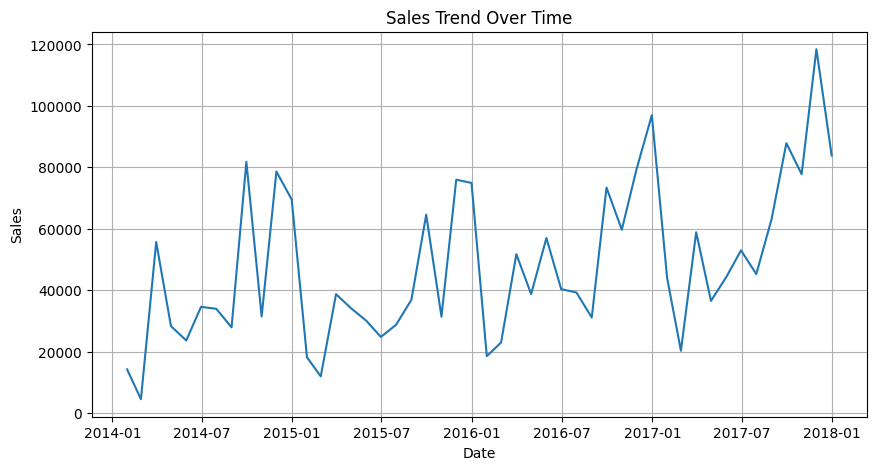


Model Trained Successfully

Predicted Sales for Next 6 Months:
[ 89160.37183913  94397.8460102   99635.32018127 104872.79435233
 110110.2685234  115347.74269447]


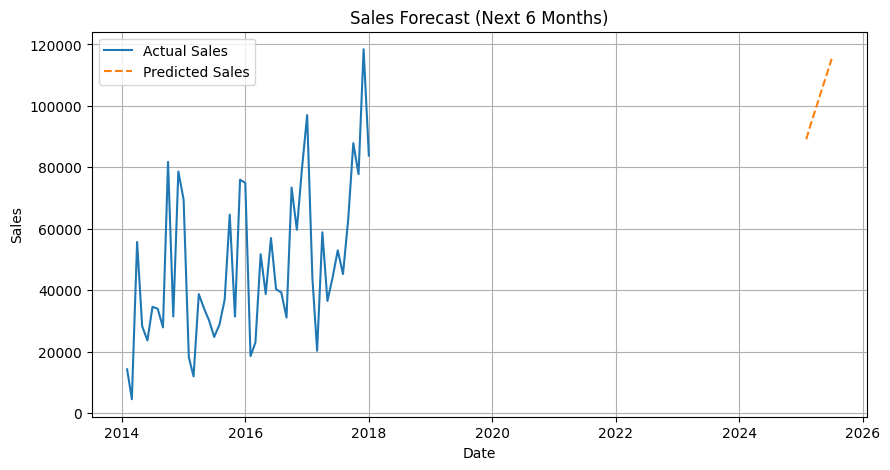


Predictions saved successfully in outputs/predictions.csv

Final Prediction Table:
   Month  Year  Predicted Sales
0      1  2025     89160.371839
1      2  2025     94397.846010
2      3  2025     99635.320181
3      4  2025    104872.794352
4      5  2025    110110.268523
5      6  2025    115347.742694

Insights:
- Sales show trends over time.
- Certain months have higher demand.
- Model helps in forecasting future sales.
- Useful for inventory planning and business decisions.
Graphs saved successfully!


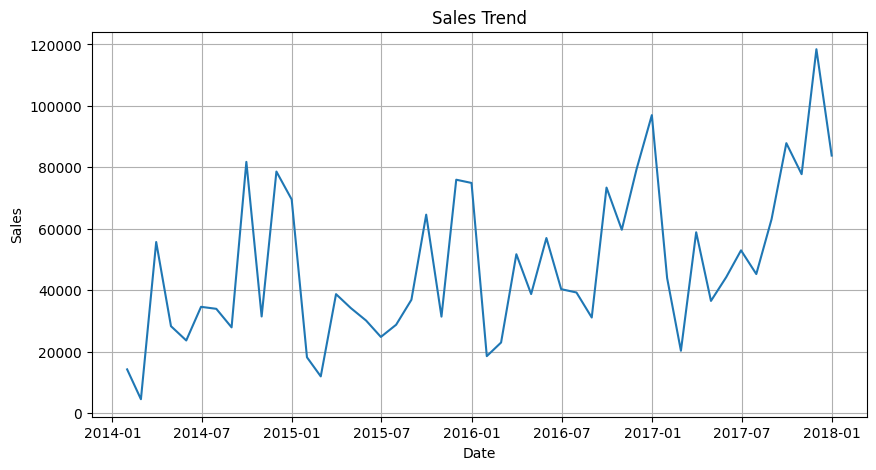

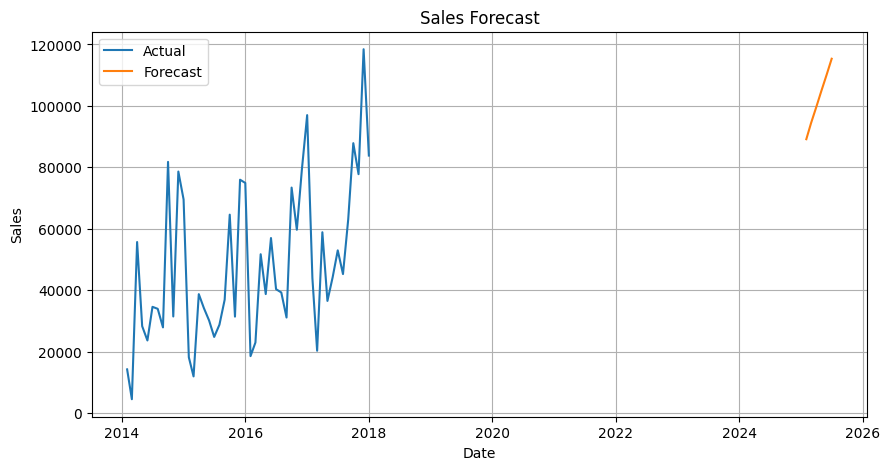

In [1]:
# 📊 Sales & Demand Forecasting (Task 1)



# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("../data/Superstore.csv", encoding='latin1')
print("Dataset Loaded Successfully")
print(df.head())

# Convert 'Order Date' to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Create Monthly Sales Data
monthly_sales = df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum().reset_index()
print("\nMonthly Sales Data:")
print(monthly_sales.head())

# Plot Sales Trend
plt.figure(figsize=(10,5))
plt.plot(monthly_sales['Order Date'], monthly_sales['Sales'])
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid()
plt.show()

# Feature Engineering
monthly_sales['Month'] = monthly_sales['Order Date'].dt.month
monthly_sales['Year'] = monthly_sales['Order Date'].dt.year

# Model Training
from sklearn.linear_model import LinearRegression

X = monthly_sales[['Month','Year']]
y = monthly_sales['Sales']

model = LinearRegression()
model.fit(X, y)

print("\nModel Trained Successfully")

# Predict Future Sales (Next 6 Months)
future = pd.DataFrame({
    'Month': [1,2,3,4,5,6],
    'Year': [2025]*6
})

predictions = model.predict(future)

print("\nPredicted Sales for Next 6 Months:")
print(predictions)

# Forecast Visualization
future_dates = pd.date_range(start='2025-01-01', periods=6, freq='ME')

plt.figure(figsize=(10,5))
plt.plot(monthly_sales['Order Date'], monthly_sales['Sales'], label="Actual Sales")
plt.plot(future_dates, predictions, label="Predicted Sales", linestyle='--')
plt.legend()
plt.title("Sales Forecast (Next 6 Months)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid()
plt.show()

# Save Predictions
future['Predicted Sales'] = predictions
future.to_csv("../outputs/predictions.csv", index=False)

print("\nPredictions saved successfully in outputs/predictions.csv")

# Final Output Table
print("\nFinal Prediction Table:")
print(future)

# 💡 Insights
print("\nInsights:")
print("- Sales show trends over time.")
print("- Certain months have higher demand.")
print("- Model helps in forecasting future sales.")
print("- Useful for inventory planning and business decisions.")

# Save Sales Trend Graph
plt.figure(figsize=(10,5))
plt.plot(monthly_sales['Order Date'], monthly_sales['Sales'])
plt.title("Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid()
plt.savefig("../outputs/sales_trend.png")

# Save Forecast Graph
plt.figure(figsize=(10,5))
plt.plot(monthly_sales['Order Date'], monthly_sales['Sales'], label="Actual")
plt.plot(future_dates, predictions, label="Forecast")
plt.legend()
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid()
plt.savefig("../outputs/forecast.png")

print("Graphs saved successfully!")


